# 📓 Notebook 03 – Exploratory Data Analysis
## Lettuce Fresh Weight Prediction | ANN + PSO

**Mode: Local (VS Code)**

Analisis:
1. Missing Values
2. Distribusi Berat
3. Correlation Heatmap
4. Distribusi Fitur
5. Outlier Detection
6. Distribusi Warna

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.edgecolor': '#0f3460', 'grid.color': '#0f3460', 'axes.grid': True,
})
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
BASE_DIR = r'D:/laragon/www/lettuce-weight-prediction'

df = pd.read_csv(f'{BASE_DIR}/data/dataset.csv')

FEATURE_COLUMNS = [
    'leaf_area', 'perimeter', 'aspect_ratio', 'extent', 'equivalent_diameter',
    'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V', 'std_G',
    'contrast', 'energy', 'homogeneity', 'correlation', 'entropy'
]

print(f'✅ Dataset: {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'📈 Berat: {df["weight_gram"].min():.1f}g – {df["weight_gram"].max():.1f}g')
print(f'📊 Rata-rata: {df["weight_gram"].mean():.2f}g | Std: {df["weight_gram"].std():.2f}g')
df.describe().round(3)

✅ Dataset: 200 baris × 18 kolom
📈 Berat: 18.0g – 45.0g
📊 Rata-rata: 31.97g | Std: 5.88g


,leaf_area,perimeter,aspect_ratio,extent,equivalent_diameter,mean_R,mean_G,mean_B,mean_H,mean_S,mean_V,std_G,contrast,energy,homogeneity,correlation,entropy,weight_gram
count,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000
mean,55305.385,1359.471,2.600,0.559,263.375,101.074,108.123,54.779,32.796,131.794,108.907,20.891,0.291,0.523,0.919,0.928,4.354,31.970
std,13791.207,196.677,0.409,0.056,32.495,8.928,9.983,6.879,1.423,10.937,9.932,2.259,0.052,0.032,0.012,0.011,0.104,5.884
min,30583.000,890.090,1.701,0.412,197.331,66.985,72.113,30.867,28.098,92.520,73.040,14.236,0.168,0.451,0.888,0.884,3.968,18.000
25%,46207.125,1237.119,2.319,0.522,242.555,97.251,103.414,51.166,31.787,123.881,104.596,19.320,0.263,0.500,0.911,0.922,4.303,28.000
50%,52828.000,1354.123,2.571,0.554,259.351,101.092,107.955,54.093,32.804,130.725,108.894,20.702,0.291,0.522,0.919,0.929,4.353,31.000
75%,63263.250,1484.574,2.852,0.602,283.812,104.356,112.694,58.603,33.774,139.839,113.670,22.231,0.318,0.540,0.927,0.934,4.415,36.000
max,107940.000,1823.872,3.762,0.716,370.720,141.867,151.927,81.523,35.606,165.783,153.012,29.138,0.539,0.621,0.947,0.951,4.637,45.000


## A. Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
m_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
m_df = m_df[m_df['Count'] > 0]

print('🔍 MISSING VALUES:')
if len(m_df) == 0:
    print('✅ Tidak ada missing values – dataset bersih!')
else:
    print(m_df)
    fig, ax = plt.subplots(figsize=(10,4))
    m_df['Percentage'].plot(kind='bar', ax=ax, color='#E74C3C')
    ax.set_title('Missing Values per Kolom', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()

🔍 MISSING VALUES:
✅ Tidak ada missing values – dataset bersih!


## B. Distribusi Berat Segar Selada

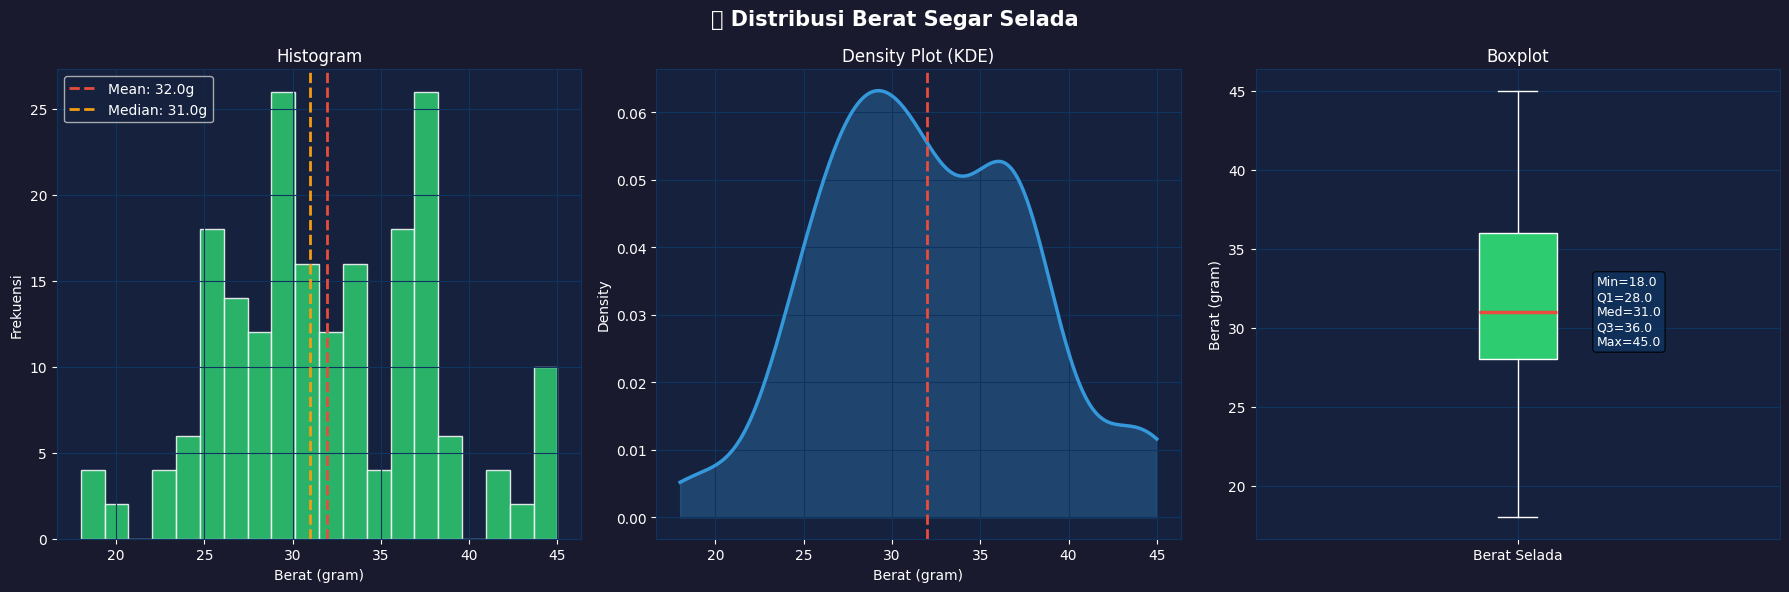

✅ Simpan → output/plots/weight_distribution.png


In [4]:
weights = df['weight_gram']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🥬 Distribusi Berat Segar Selada', fontsize=15, fontweight='bold', color='white')

# Histogram
axes[0].hist(weights, bins=20, color='#2ECC71', edgecolor='white', alpha=0.85)
axes[0].axvline(weights.mean(),   color='#E74C3C', linestyle='--', lw=2, label=f'Mean: {weights.mean():.1f}g')
axes[0].axvline(weights.median(), color='#F39C12', linestyle='--', lw=2, label=f'Median: {weights.median():.1f}g')
axes[0].set_title('Histogram', fontsize=12)
axes[0].set_xlabel('Berat (gram)'); axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# KDE
kde  = gaussian_kde(weights)
x_r  = np.linspace(weights.min(), weights.max(), 200)
axes[1].plot(x_r, kde(x_r), color='#3498DB', lw=2.5)
axes[1].fill_between(x_r, kde(x_r), alpha=0.3, color='#3498DB')
axes[1].axvline(weights.mean(), color='#E74C3C', lw=2, linestyle='--')
axes[1].set_title('Density Plot (KDE)', fontsize=12)
axes[1].set_xlabel('Berat (gram)'); axes[1].set_ylabel('Density')

# Boxplot
bp = axes[2].boxplot(weights, patch_artist=True,
                      boxprops=dict(facecolor='#2ECC71', color='white'),
                      medianprops=dict(color='#E74C3C', lw=2.5),
                      whiskerprops=dict(color='white'),
                      capprops=dict(color='white'),
                      flierprops=dict(marker='o', color='#E74C3C', alpha=0.6))
axes[2].set_title('Boxplot', fontsize=12)
axes[2].set_ylabel('Berat (gram)')
axes[2].set_xticklabels(['Berat Selada'])
stats_txt = f'Min={weights.min():.1f}\nQ1={weights.quantile(.25):.1f}\nMed={weights.median():.1f}\nQ3={weights.quantile(.75):.1f}\nMax={weights.max():.1f}'
axes[2].text(1.15, weights.median(), stats_txt, fontsize=9, color='white', va='center',
              bbox=dict(boxstyle='round', facecolor='#0f3460', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/weight_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/weight_distribution.png')

## C. Correlation Heatmap

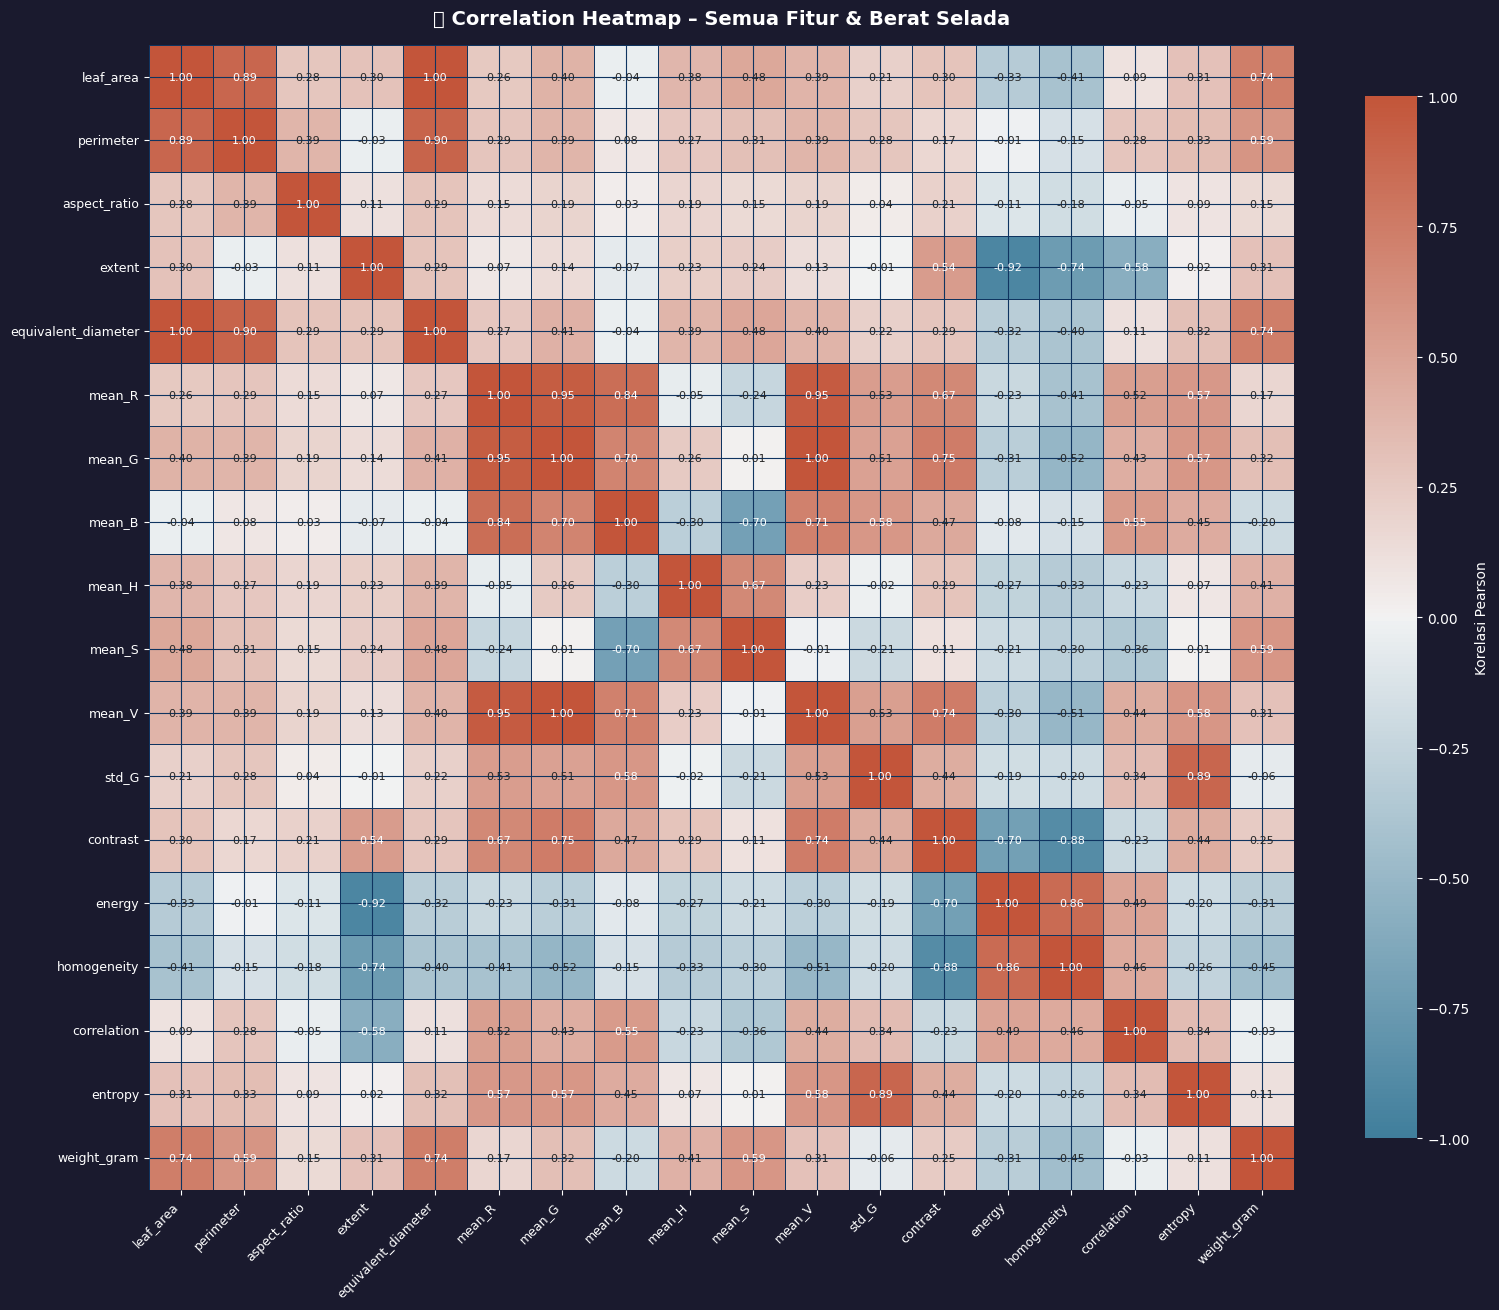

✅ Simpan → output/plots/correlation_heatmap.png

📊 Top 10 Fitur Korelasi dengan Berat:
   1. equivalent_diameter      : +0.7410 |██████████████
   2. leaf_area                : +0.7408 |██████████████
   3. perimeter                : +0.5872 |███████████
   4. mean_S                   : +0.5854 |███████████
   5. homogeneity              : -0.4465 |████████
   6. mean_H                   : +0.4071 |████████
   7. mean_G                   : +0.3214 |██████
   8. energy                   : -0.3138 |██████
   9. extent                   : +0.3115 |██████
  10. mean_V                   : +0.3078 |██████


In [5]:
corr_cols   = FEATURE_COLUMNS + ['weight_gram']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, ax=ax,
    annot=True, fmt='.2f', cmap=cmap,
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='#0f3460',
    cbar_kws={'shrink': 0.8, 'label': 'Korelasi Pearson'},
    annot_kws={'size': 8}
)

ax.set_title('🔥 Correlation Heatmap – Semua Fitur & Berat Selada',
              fontsize=14, fontweight='bold', color='white', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9, color='white')
plt.yticks(rotation=0, fontsize=9, color='white')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/correlation_heatmap.png')

# Top korelasi
w_corr = corr_matrix['weight_gram'].drop('weight_gram').sort_values(key=abs, ascending=False)
print('\n📊 Top 10 Fitur Korelasi dengan Berat:')
for i, (feat, val) in enumerate(w_corr.head(10).items(), 1):
    bar = '█' * int(abs(val)*20)
    print(f'  {i:2d}. {feat:25s}: {"+" if val>0 else "-"}{abs(val):.4f} |{bar}')

## D. Distribusi Setiap Fitur

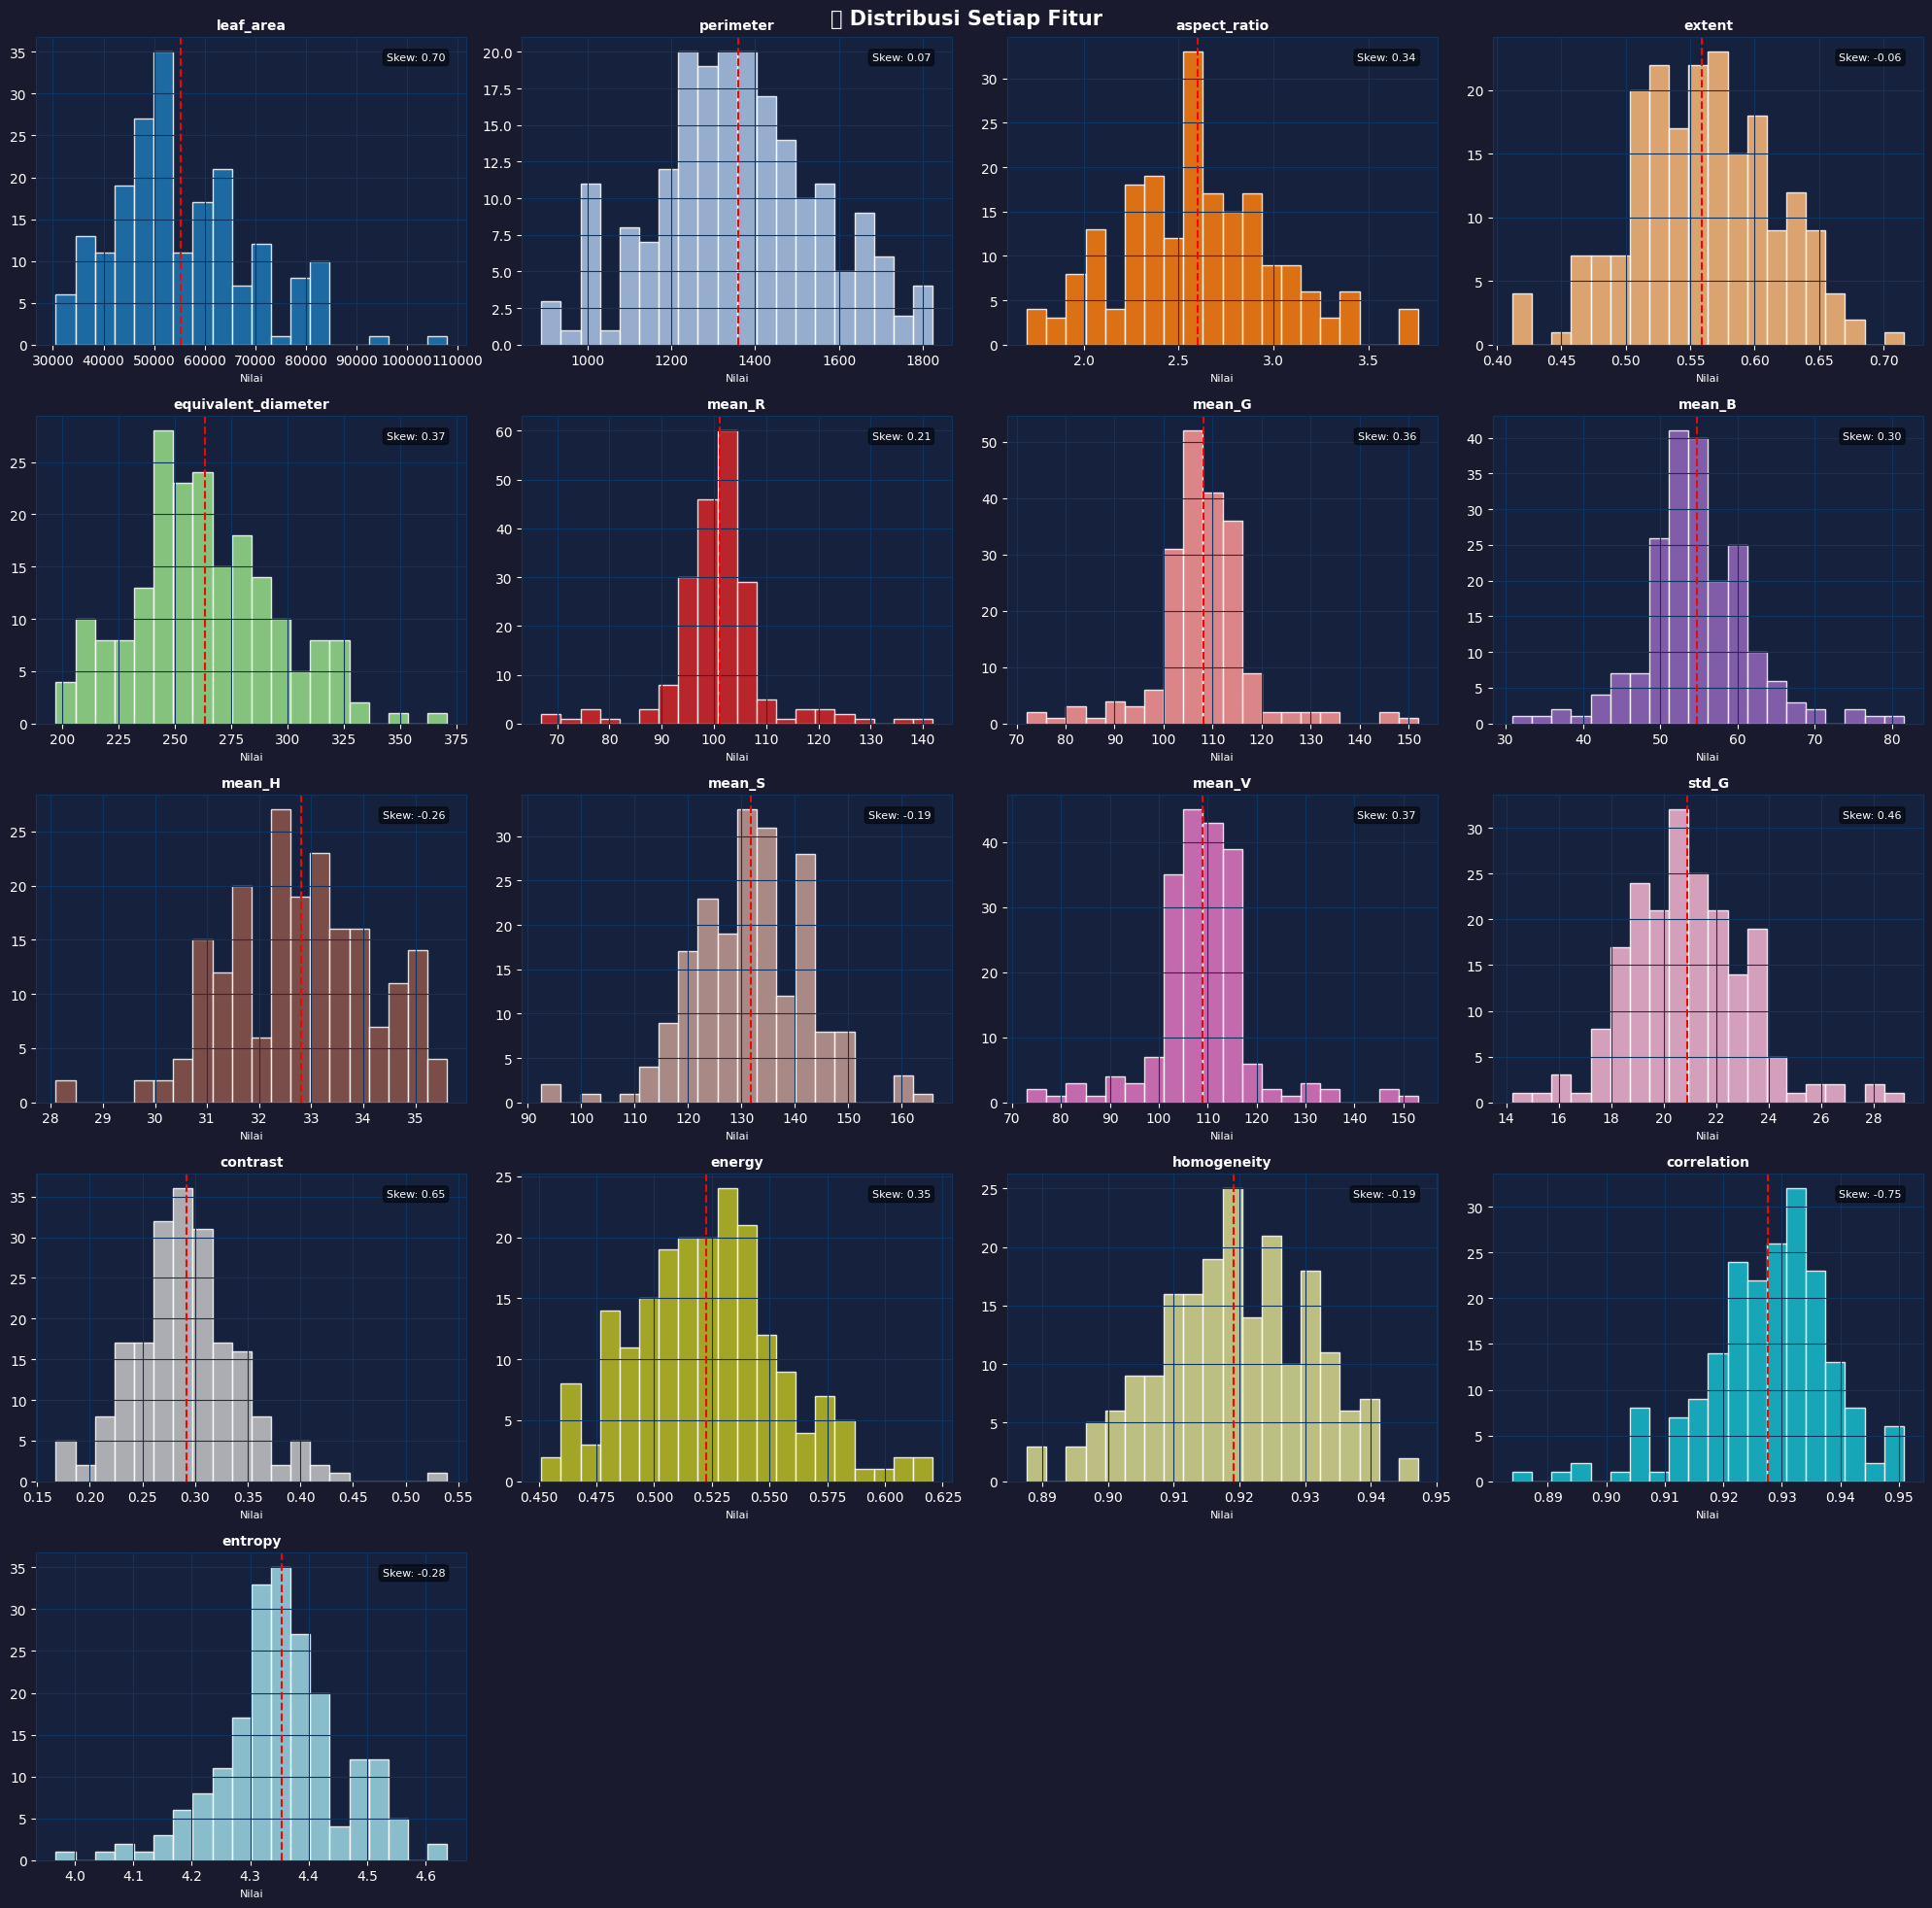

✅ Simpan → output/plots/feature_distributions.png


In [6]:
n_cols = 4
n_rows = (len(FEATURE_COLUMNS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('📊 Distribusi Setiap Fitur', fontsize=15, fontweight='bold', color='white')

palette = plt.cm.tab20(np.linspace(0, 1, len(FEATURE_COLUMNS)))

for idx, (feat, color) in enumerate(zip(FEATURE_COLUMNS, palette)):
    r, c = idx // n_cols, idx % n_cols
    ax   = axes[r, c] if n_rows > 1 else axes[c]
    data = df[feat].dropna()
    ax.hist(data, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', ls='--', lw=1.5)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=8)
    ax.text(0.95, 0.95, f'Skew: {data.skew():.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

for idx in range(len(FEATURE_COLUMNS), n_rows * n_cols):
    r, c = idx // n_cols, idx % n_cols
    (axes[r, c] if n_rows > 1 else axes[c]).axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/feature_distributions.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/feature_distributions.png')

## E. Outlier Detection (IQR)

📦 OUTLIER DETECTION (IQR Method)
  leaf_area                :   2 outlier (1.0%) |██
  perimeter                :   0 outlier (0.0%) |
  aspect_ratio             :   4 outlier (2.0%) |████
  extent                   :   0 outlier (0.0%) |
  equivalent_diameter      :   2 outlier (1.0%) |██
  mean_R                   :  18 outlier (9.0%) |██████████████████
  mean_G                   :  15 outlier (7.5%) |███████████████
  mean_B                   :   9 outlier (4.5%) |█████████
  mean_H                   :   2 outlier (1.0%) |██
  mean_S                   :   3 outlier (1.5%) |███
  mean_V                   :  15 outlier (7.5%) |███████████████
  std_G                    :   6 outlier (3.0%) |██████
  contrast                 :  10 outlier (5.0%) |██████████
  energy                   :   4 outlier (2.0%) |████
  homogeneity              :   0 outlier (0.0%) |
  correlation              :   4 outlier (2.0%) |████
  entropy                  :   7 outlier (3.5%) |███████
  weight_gram   

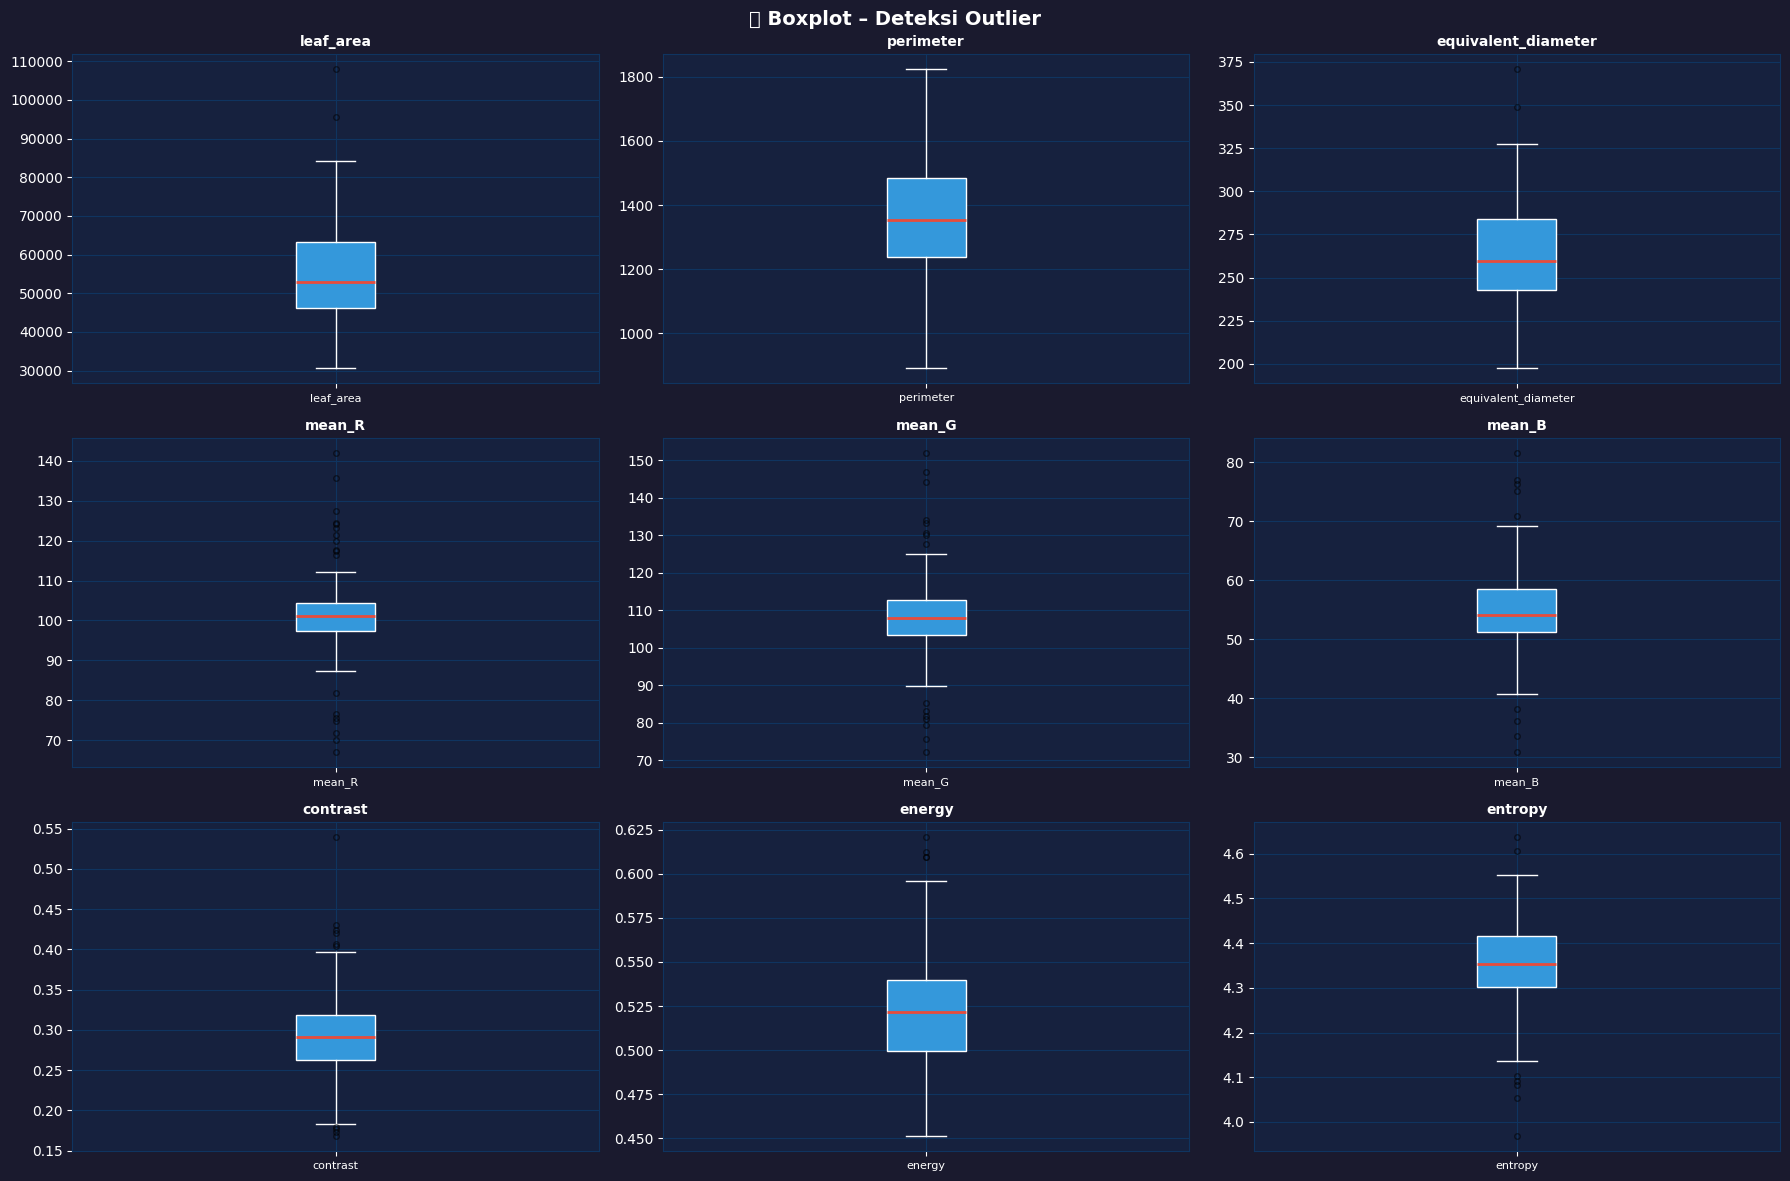

✅ Simpan → output/plots/outlier_boxplots.png


In [7]:
print('📦 OUTLIER DETECTION (IQR Method)')
print('=' * 45)

for feat in FEATURE_COLUMNS + ['weight_gram']:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    pct    = n_out / len(df) * 100
    bar    = '█' * n_out
    print(f'  {feat:25s}: {n_out:3d} outlier ({pct:.1f}%) |{bar}')

# Boxplot fitur utama
key_feats = ['leaf_area', 'perimeter', 'equivalent_diameter',
             'mean_R', 'mean_G', 'mean_B', 'contrast', 'energy', 'entropy']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('📦 Boxplot – Deteksi Outlier', fontsize=14, fontweight='bold', color='white')

for ax, feat in zip(axes.flatten(), key_feats):
    ax.boxplot(df[feat].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498DB', color='white'),
               medianprops=dict(color='#E74C3C', lw=2),
               whiskerprops=dict(color='white'), capprops=dict(color='white'),
               flierprops=dict(marker='o', color='#E74C3C', alpha=0.5, ms=4))
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xticklabels([feat], fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/outlier_boxplots.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Simpan → output/plots/outlier_boxplots.png')

## F. Distribusi Warna

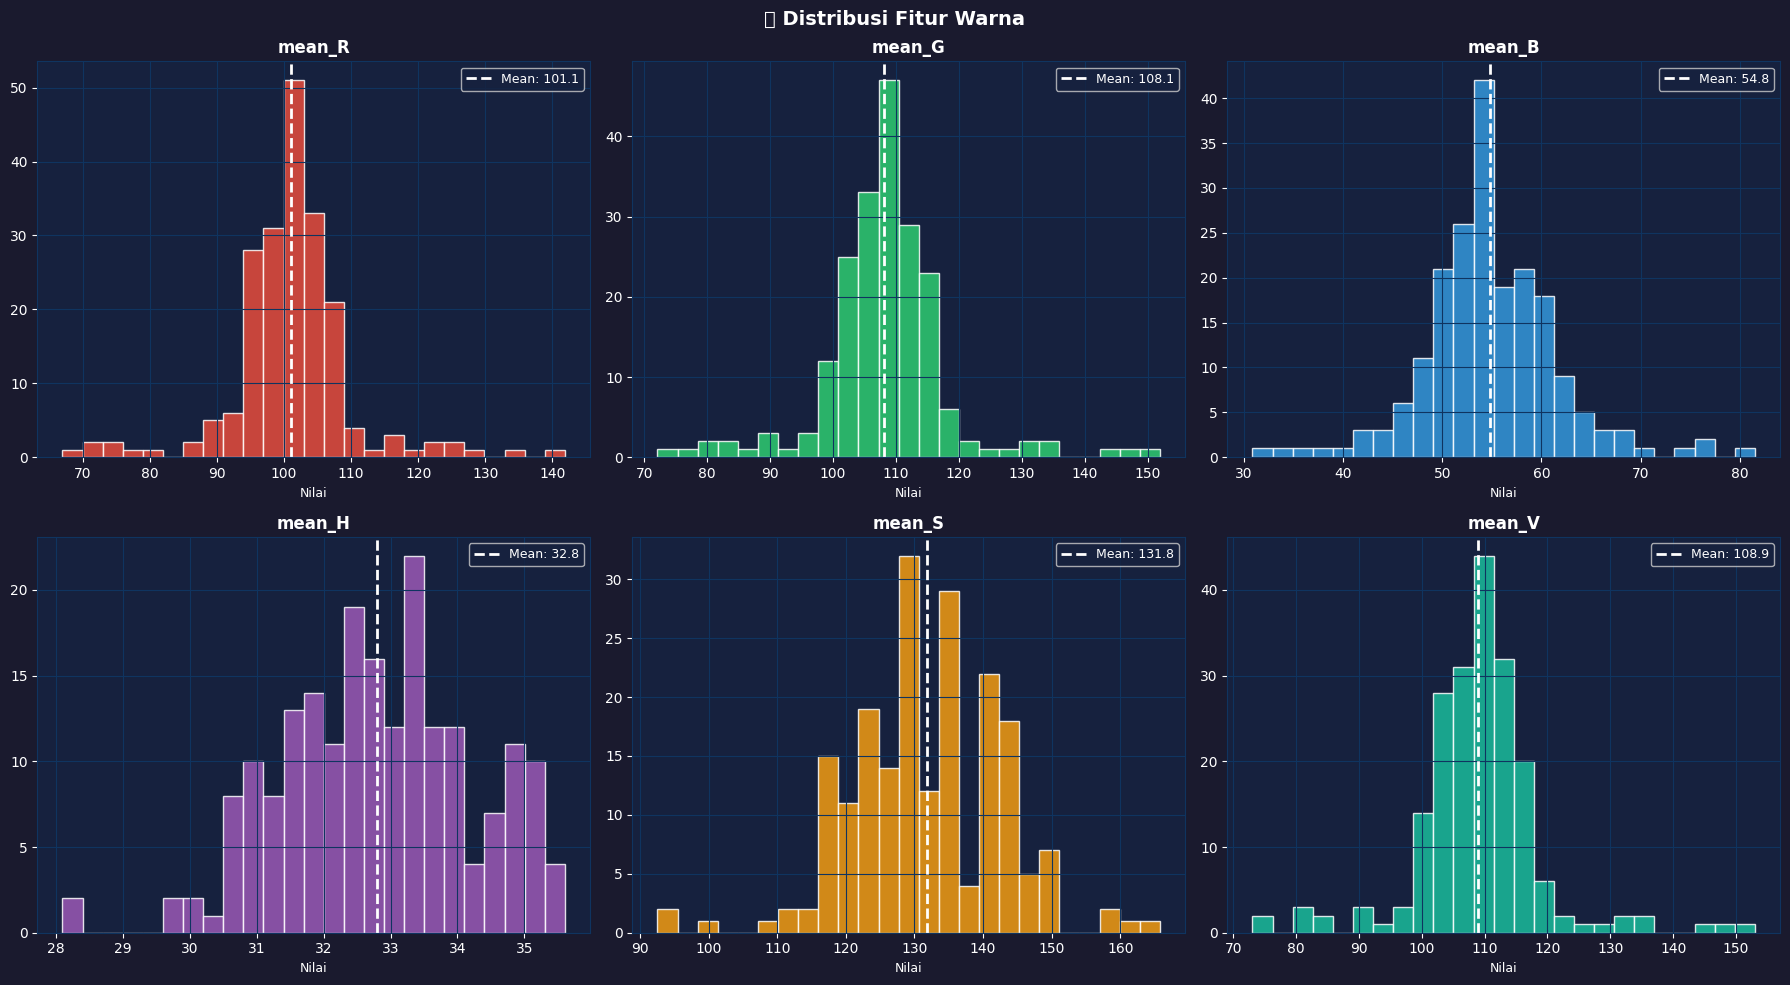

✅ NOTEBOOK 03 SELESAI!
📁 Plot yang dihasilkan:
   ✅ output/plots/weight_distribution.png
   ✅ output/plots/correlation_heatmap.png
   ✅ output/plots/feature_distributions.png
   ✅ output/plots/outlier_boxplots.png
   ✅ output/plots/color_distribution.png

📌 Lanjut → 04_ANN_Model.ipynb


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🎨 Distribusi Fitur Warna', fontsize=14, fontweight='bold', color='white')

color_feats = [('mean_R','#E74C3C'), ('mean_G','#2ECC71'), ('mean_B','#3498DB'),
               ('mean_H','#9B59B6'), ('mean_S','#F39C12'), ('mean_V','#1ABC9C')]

for ax, (feat, color) in zip(axes.flatten(), color_feats):
    data = df[feat].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='white', ls='--', lw=2, label=f'Mean: {data.mean():.1f}')
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/output/plots/color_distribution.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('=' * 55)
print('✅ NOTEBOOK 03 SELESAI!')
print('=' * 55)
print('📁 Plot yang dihasilkan:')
for p in ['weight_distribution.png','correlation_heatmap.png',
          'feature_distributions.png','outlier_boxplots.png','color_distribution.png']:
    print(f'   ✅ output/plots/{p}')
print()
print('📌 Lanjut → 04_ANN_Model.ipynb')